In [1]:
import torch
print('torch', torch.__version__, 'cuda', torch.version.cuda, 'gpu', torch.cuda.is_available())

TORCH_VER = torch.__version__.split('+')[0]
CUDA_VER = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'
print('Using wheel index:', f'https://data.pyg.org/whl/torch-{TORCH_VER}+{CUDA_VER}.html')

!pip install -q torch_geometric
!pip install -q torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{TORCH_VER}+{CUDA_VER}.html

import torch_geometric
print('torch_geometric', torch_geometric.__version__)

torch 2.10.0+cu128 cuda 12.8 gpu True
Using wheel index: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 91.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.1 MB/s eta 0:00:00
torch_geometric 2.7.0


In [2]:
import os, time, json, math, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool, SchNet

import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

#Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

#Paths
ROOT = Path('./qm9_project')
ROOT.mkdir(exist_ok=True)
(ROOT / 'checkpoints').mkdir(exist_ok=True)
(ROOT / 'figures').mkdir(exist_ok=True)
(ROOT / 'logs').mkdir(exist_ok=True)
print('Project root:', ROOT.resolve())

Device: cuda
Project root: /kaggle/working/qm9_project


## Data: QM9 + HOMO–LUMO gap target

QM9 has 19 regression targets; the HOMO–LUMO gap is `target_idx = 4`. We follow the standard 110k/10k/10k random split with a fixed seed.

Targets are normalized to zero mean and unit variance over the **training** set; we always report metrics back in **eV**.

In [3]:
TARGET_IDX = 4   # HOMO-LUMO gap (Δε), in eV
TARGET_NAME = 'HOMO-LUMO gap (eV)'

dataset = QM9(root=str(ROOT / 'data' / 'QM9'))
print('Total molecules:', len(dataset))
print('Example sample:', dataset[0])
print('Target shape:', dataset[0].y.shape)

# Replacing y with just the gap target
class SingleTarget(torch.utils.data.Dataset):
    def __init__(self, base, idx):
        self.base, self.idx = base, idx
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        d = self.base[i].clone()
        d.y = d.y[:, self.idx:self.idx+1]   # keeping shape [1, 1]
        return d

# Random split with fixed seed
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(len(dataset), generator=g).tolist()
n_train, n_val, n_test = 110_000, 10_000, 10_000
assert n_train + n_val + n_test <= len(dataset)
train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train+n_val]
test_idx  = perm[n_train+n_val:n_train+n_val+n_test]

single = SingleTarget(dataset, TARGET_IDX)
train_set_full = [single[i] for i in train_idx]
val_set        = [single[i] for i in val_idx]
test_set       = [single[i] for i in test_idx]

# Computing training set mean/std for target normalization
ys = torch.cat([d.y for d in train_set_full]).view(-1)
TARGET_MEAN, TARGET_STD = float(ys.mean()), float(ys.std())
print(f'{TARGET_NAME}:  mean={TARGET_MEAN:.4f}  std={TARGET_STD:.4f}')

def loaders(train_set, batch_size=128, num_workers=2):
    return (
        DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=num_workers),
        DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=num_workers),
        DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=num_workers),
    )

Extracting qm9_project/data/QM9/raw/qm9_v3.zip
Processing...
Using a pre-processed version of the dataset. Please install 'rdkit' to alternatively process the raw data.
Done!


Total molecules: 130831
Example sample: Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5])
Target shape: torch.Size([1, 19])
HOMO-LUMO gap (eV):  mean=6.8580  std=1.2831


## Models

### Baseline: GCN
Standard Kipf–Welling GCN, mean-pooled atom features, 2-layer MLP head. **Uses bond connectivity only — no 3D coordinates.**

In [4]:
class GCNRegressor(nn.Module):
    """GCN baseline. Reads x (atom features) + edge_index. Ignores 3D coords."""
    def __init__(self, in_dim=11, hidden=128, n_layers=3, dropout=0.0):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden))
        for _ in range(n_layers - 1):
            self.convs.append(GCNConv(hidden, hidden))
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 1),
        )
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x.float(), data.edge_index, data.batch
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.silu(x)
            if self.dropout > 0:
                x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_mean_pool(x, batch)
        return self.head(x).squeeze(-1)

def make_gcn():
    return GCNRegressor(in_dim=11, hidden=128, n_layers=3).to(DEVICE)

# sanity check
_loader = DataLoader(train_set_full[:8], batch_size=4)
_m = make_gcn()
for b in _loader:
    b = b.to(DEVICE)
    out = _m(b)
    print('GCN output shape:', out.shape, '(expected [batch_size])')
    break

GCN output shape: torch.Size([4]) (expected [batch_size])


### Variant: SchNet
We use the canonical PyG `SchNet` implementation (continuous-filter convolutions over 3D distances, 6 interaction blocks, RBF distance expansion, 10 Å cutoff). It outputs an atom-summed scalar prediction; we add a linear head for target normalization handling.

In [5]:
from torch_geometric.nn import SchNet
from torch_geometric.nn.models.schnet import GaussianSmearing

class _BatchedRadiusGraph(torch.nn.Module):
    """Pure-PyTorch replacement for SchNet's RadiusInteractionGraph.
    Avoids the torch_cluster dependency.
    """
    def __init__(self, cutoff: float, max_num_neighbors: int = 32):
        super().__init__()
        self.cutoff = cutoff
        self.max_num_neighbors = max_num_neighbors

    def forward(self, pos, batch):
        same_graph = batch.unsqueeze(0) == batch.unsqueeze(1)        
        diff = pos.unsqueeze(0) - pos.unsqueeze(1)                   
        dist = diff.norm(dim=-1)                                     
        mask = same_graph & (dist <= self.cutoff) & (dist > 1e-8)    
        row, col = mask.nonzero(as_tuple=True)
        edge_index = torch.stack([row, col], dim=0)
        edge_weight = dist[row, col]
        return edge_index, edge_weight


class SchNetRegressor(nn.Module):
    """SchNet variant. Replaces the radius-graph builder with a torch-only
    version"""
    def __init__(self, hidden=128, n_filters=128, n_interactions=6,
                 n_gauss=50, cutoff=10.0):
        super().__init__()
        self.net = SchNet(
            hidden_channels=hidden,
            num_filters=n_filters,
            num_interactions=n_interactions,
            num_gaussians=n_gauss,
            cutoff=cutoff,
        )
        self.net.interaction_graph = _BatchedRadiusGraph(cutoff=cutoff)

    def forward(self, data):
        return self.net(data.z, data.pos, data.batch).squeeze(-1)


def make_schnet():
    return SchNetRegressor().to(DEVICE)

# sanity check
_m = make_schnet()
for b in _loader:
    b = b.to(DEVICE)
    out = _m(b)
    print('SchNet output shape:', out.shape, '(expected [batch_size])')
    break

def n_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f'GCN params:    {n_params(make_gcn()):,}')
print(f'SchNet params: {n_params(make_schnet()):,}')

SchNet output shape: torch.Size([4]) (expected [batch_size])
GCN params:    51,201
SchNet params: 455,809


## Training and evaluation

Both models are trained with the **same loop, optimizer, and stopping criterion** so the only thing varying is the architecture. Targets are normalized during training; MAE is reported in eV (and meV).

In [6]:
def normalize(y):    return (y - TARGET_MEAN) / TARGET_STD
def denormalize(y):  return y * TARGET_STD + TARGET_MEAN

@torch.no_grad()
def evaluate(model, loader):
    """Return MAE in eV on the original scale."""
    model.eval()
    abs_errs, n = 0.0, 0
    sq_errs, sum_y, sum_y2 = 0.0, 0.0, 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        pred_norm = model(batch)
        pred = denormalize(pred_norm)
        y = batch.y.view(-1)
        abs_errs += (pred - y).abs().sum().item()
        sq_errs  += ((pred - y) ** 2).sum().item()
        sum_y    += y.sum().item()
        sum_y2   += (y ** 2).sum().item()
        n += y.numel()
    mae = abs_errs / n
    mse = sq_errs / n
    var_y = sum_y2/n - (sum_y/n)**2
    r2 = 1.0 - mse / (var_y + 1e-12)
    return {'mae_eV': mae, 'mae_meV': mae * 1000.0, 'rmse_eV': math.sqrt(mse), 'r2': r2}

def train_one(model, train_set, val_set, *, name, epochs=150, batch_size=128,
              lr=1e-3, weight_decay=0.0, patience=20, log_every=1):
    """Train one model. Returns dict with best val MAE, full history, and best-state dict."""
    train_loader, val_loader, _ = loaders(train_set, batch_size=batch_size)
    optim = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=8)
    history = {'epoch': [], 'train_loss': [], 'val_mae_meV': [], 'lr': []}
    best_val, best_state, bad = float('inf'), None, 0
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        running, ntot = 0.0, 0
        for batch in train_loader:
            batch = batch.to(DEVICE)
            optim.zero_grad()
            pred_norm = model(batch)
            target_norm = normalize(batch.y.view(-1))
            loss = F.l1_loss(pred_norm, target_norm)
            loss.backward()
            optim.step()
            running += loss.item() * batch.num_graphs
            ntot += batch.num_graphs
        train_loss = running / ntot
        val = evaluate(model, val_loader)
        sched.step(val['mae_meV'])
        history['epoch'].append(ep)
        history['train_loss'].append(train_loss)
        history['val_mae_meV'].append(val['mae_meV'])
        history['lr'].append(optim.param_groups[0]['lr'])
        if ep == 1 or ep % log_every == 0:
            print(f"[{name}] ep{ep:3d}  train_loss={train_loss:.4f}  val_MAE={val['mae_meV']:.1f} meV  lr={optim.param_groups[0]['lr']:.2e}")
        if val['mae_meV'] < best_val - 1e-6:
            best_val = val['mae_meV']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f'[{name}] early stop @ epoch {ep} (best val MAE {best_val:.1f} meV)')
                break
    elapsed = time.time() - t0
    return {'best_val_mae_meV': best_val, 'history': history, 'best_state': best_state, 'elapsed_s': elapsed}


## Main run full-data comparison 

In [7]:
# GCN baseline 
gcn = make_gcn()
gcn_run = train_one(gcn, train_set_full, val_set, name='GCN', epochs=200, batch_size=128, patience=25)
torch.save(gcn_run['best_state'], ROOT / 'checkpoints' / 'gcn_full.pt')
with open(ROOT / 'logs' / 'gcn_full.json', 'w') as f:
    json.dump({k: v for k, v in gcn_run.items() if k != 'best_state'}, f)

gcn.load_state_dict(gcn_run['best_state'])
_, _, test_loader = loaders(train_set_full)
gcn_test = evaluate(gcn, test_loader)
print('GCN TEST:', gcn_test)

[GCN] ep  1  train_loss=0.6308  val_MAE=727.9 meV  lr=1.00e-03
[GCN] ep  2  train_loss=0.5072  val_MAE=595.0 meV  lr=1.00e-03
[GCN] ep  3  train_loss=0.4457  val_MAE=539.9 meV  lr=1.00e-03
[GCN] ep  4  train_loss=0.4238  val_MAE=532.3 meV  lr=1.00e-03
[GCN] ep  5  train_loss=0.4100  val_MAE=519.8 meV  lr=1.00e-03
[GCN] ep  6  train_loss=0.3962  val_MAE=497.1 meV  lr=1.00e-03
[GCN] ep  7  train_loss=0.3826  val_MAE=469.0 meV  lr=1.00e-03
[GCN] ep  8  train_loss=0.3678  val_MAE=457.8 meV  lr=1.00e-03
[GCN] ep  9  train_loss=0.3471  val_MAE=430.7 meV  lr=1.00e-03
[GCN] ep 10  train_loss=0.3275  val_MAE=397.5 meV  lr=1.00e-03
[GCN] ep 11  train_loss=0.3074  val_MAE=387.1 meV  lr=1.00e-03
[GCN] ep 12  train_loss=0.2930  val_MAE=375.2 meV  lr=1.00e-03
[GCN] ep 13  train_loss=0.2814  val_MAE=349.0 meV  lr=1.00e-03
[GCN] ep 14  train_loss=0.2746  val_MAE=346.9 meV  lr=1.00e-03
[GCN] ep 15  train_loss=0.2694  val_MAE=336.9 meV  lr=1.00e-03
[GCN] ep 16  train_loss=0.2615  val_MAE=325.3 meV  lr=1

In [8]:
# SchNet variant 
schnet = make_schnet()
schnet_run = train_one(schnet, train_set_full, val_set, name='SchNet', epochs=150, batch_size=128, patience=20)
torch.save(schnet_run['best_state'], ROOT / 'checkpoints' / 'schnet_full.pt')
with open(ROOT / 'logs' / 'schnet_full.json', 'w') as f:
    json.dump({k: v for k, v in schnet_run.items() if k != 'best_state'}, f)

schnet.load_state_dict(schnet_run['best_state'])
schnet_test = evaluate(schnet, test_loader)
print('SchNet TEST:', schnet_test)

[SchNet] ep  1  train_loss=0.6268  val_MAE=419.0 meV  lr=1.00e-03
[SchNet] ep  2  train_loss=0.2899  val_MAE=367.2 meV  lr=1.00e-03
[SchNet] ep  3  train_loss=0.2448  val_MAE=273.2 meV  lr=1.00e-03
[SchNet] ep  4  train_loss=0.2121  val_MAE=260.9 meV  lr=1.00e-03
[SchNet] ep  5  train_loss=0.1970  val_MAE=226.5 meV  lr=1.00e-03
[SchNet] ep  6  train_loss=0.1807  val_MAE=235.7 meV  lr=1.00e-03
[SchNet] ep  7  train_loss=0.1696  val_MAE=227.9 meV  lr=1.00e-03
[SchNet] ep  8  train_loss=0.1586  val_MAE=184.2 meV  lr=1.00e-03
[SchNet] ep  9  train_loss=0.1480  val_MAE=224.6 meV  lr=1.00e-03
[SchNet] ep 10  train_loss=0.1413  val_MAE=168.6 meV  lr=1.00e-03
[SchNet] ep 11  train_loss=0.1342  val_MAE=169.7 meV  lr=1.00e-03
[SchNet] ep 12  train_loss=0.1282  val_MAE=149.6 meV  lr=1.00e-03
[SchNet] ep 13  train_loss=0.1220  val_MAE=152.1 meV  lr=1.00e-03
[SchNet] ep 14  train_loss=0.1165  val_MAE=154.0 meV  lr=1.00e-03
[SchNet] ep 15  train_loss=0.1137  val_MAE=147.1 meV  lr=1.00e-03
[SchNet] e

In [9]:
print(f"{'Model':<10} {'Test MAE (meV)':>16} {'R^2':>8} {'Time (s)':>10}")
print('-' * 50)
print(f"{'GCN':<10} {gcn_test['mae_meV']:>16.2f} {gcn_test['r2']:>8.3f} {gcn_run['elapsed_s']:>10.0f}")
print(f"{'SchNet':<10} {schnet_test['mae_meV']:>16.2f} {schnet_test['r2']:>8.3f} {schnet_run['elapsed_s']:>10.0f}")

Model        Test MAE (meV)      R^2   Time (s)
--------------------------------------------------
GCN                  174.17    0.963       3337
SchNet                51.99    0.996       5368


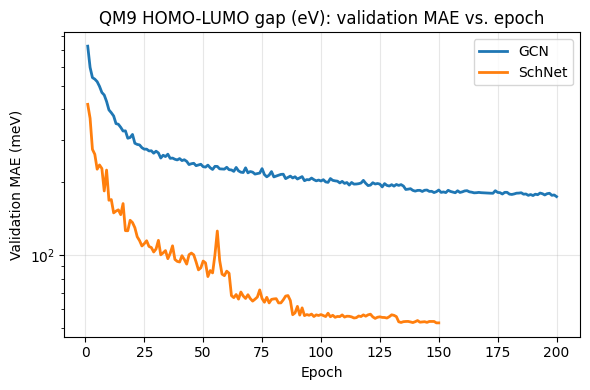

Saved to qm9_project/figures/training_curves.pdf


In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
h = gcn_run['history'];     ax.plot(h['epoch'], h['val_mae_meV'], label='GCN', linewidth=2)
h = schnet_run['history'];  ax.plot(h['epoch'], h['val_mae_meV'], label='SchNet', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation MAE (meV)')
ax.set_yscale('log')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title(f'QM9 {TARGET_NAME}: validation MAE vs. epoch')
fig.tight_layout()
fig.savefig(ROOT / 'figures' / 'training_curves.pdf')
fig.savefig(ROOT / 'figures' / 'training_curves.png', dpi=150)
plt.show()
print('Saved to', ROOT / 'figures' / 'training_curves.pdf')

## learning curves vs. training set size

Retraining both models on subsets of size 5k, 20k, 50k, and 110k. **Reuses the same val/test splits** so all points are comparable. Each smaller run is faster (fewer batches per epoch).

In [11]:
SIZES = [5_000, 20_000, 50_000]   
lc_results = {'GCN': {}, 'SchNet': {}}

for n in SIZES:
    sub = train_set_full[:n]

    g = make_gcn()
    r = train_one(g, sub, val_set, name=f'GCN-{n}', epochs=150, patience=20, log_every=10)
    g.load_state_dict(r['best_state'])
    lc_results['GCN'][n] = evaluate(g, test_loader)
    torch.save(r['best_state'], ROOT / 'checkpoints' / f'gcn_n{n}.pt')

    s = make_schnet()
    r = train_one(s, sub, val_set, name=f'SchNet-{n}', epochs=120, patience=15, log_every=10)
    s.load_state_dict(r['best_state'])
    lc_results['SchNet'][n] = evaluate(s, test_loader)
    torch.save(r['best_state'], ROOT / 'checkpoints' / f'schnet_n{n}.pt')

lc_results['GCN'][n_train]    = gcn_test
lc_results['SchNet'][n_train] = schnet_test

with open(ROOT / 'logs' / 'learning_curves.json', 'w') as f:
    json.dump(lc_results, f, indent=2)

for model, runs in lc_results.items():
    for n, m in sorted(runs.items()):
        print(f'{model:>7s}  N={n:>6d}  test MAE = {m["mae_meV"]:7.2f} meV   R^2 = {m["r2"]:.3f}')

[GCN-5000] ep  1  train_loss=0.7938  val_MAE=929.5 meV  lr=1.00e-03
[GCN-5000] ep 10  train_loss=0.6358  val_MAE=809.6 meV  lr=1.00e-03
[GCN-5000] ep 20  train_loss=0.5792  val_MAE=748.2 meV  lr=1.00e-03
[GCN-5000] ep 30  train_loss=0.5240  val_MAE=687.1 meV  lr=1.00e-03
[GCN-5000] ep 40  train_loss=0.4820  val_MAE=641.2 meV  lr=1.00e-03
[GCN-5000] ep 50  train_loss=0.4524  val_MAE=589.2 meV  lr=1.00e-03
[GCN-5000] ep 60  train_loss=0.4395  val_MAE=550.9 meV  lr=1.00e-03
[GCN-5000] ep 70  train_loss=0.4251  val_MAE=545.6 meV  lr=1.00e-03
[GCN-5000] ep 80  train_loss=0.4170  val_MAE=547.0 meV  lr=1.00e-03
[GCN-5000] ep 90  train_loss=0.4178  val_MAE=531.0 meV  lr=1.00e-03
[GCN-5000] ep100  train_loss=0.4105  val_MAE=513.4 meV  lr=1.00e-03
[GCN-5000] ep110  train_loss=0.4010  val_MAE=528.1 meV  lr=1.00e-03
[GCN-5000] ep120  train_loss=0.4022  val_MAE=543.5 meV  lr=1.00e-03
[GCN-5000] ep130  train_loss=0.3940  val_MAE=499.6 meV  lr=1.00e-03
[GCN-5000] ep140  train_loss=0.3913  val_MAE=502

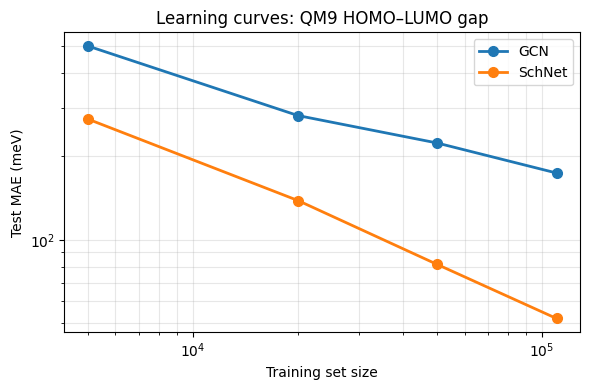

Saved to qm9_project/figures/learning_curves.pdf


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
for model in ['GCN', 'SchNet']:
    runs = sorted(lc_results[model].items())
    xs = [n for n, _ in runs]
    ys = [m['mae_meV'] for _, m in runs]
    ax.plot(xs, ys, 'o-', label=model, linewidth=2, markersize=7)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Training set size'); ax.set_ylabel('Test MAE (meV)')
ax.set_title('Learning curves: QM9 HOMO–LUMO gap')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(ROOT / 'figures' / 'learning_curves.pdf')
fig.savefig(ROOT / 'figures' / 'learning_curves.png', dpi=150)
plt.show()
print('Saved to', ROOT / 'figures' / 'learning_curves.pdf')

In [13]:
def reproduce():
    _, _, test_loader = loaders(train_set_full)

    g = make_gcn()
    g.load_state_dict(torch.load(ROOT / 'checkpoints' / 'gcn_full.pt', map_location=DEVICE))
    print('GCN TEST   :', evaluate(g, test_loader))

    s = make_schnet()
    s.load_state_dict(torch.load(ROOT / 'checkpoints' / 'schnet_full.pt', map_location=DEVICE))
    print('SchNet TEST:', evaluate(s, test_loader))

reproduce()

GCN TEST   : {'mae_eV': 0.1741700571537018, 'mae_meV': 174.17005715370178, 'rmse_eV': 0.24783429522595973, 'r2': 0.9632331342981013}
SchNet TEST: {'mae_eV': 0.05199331851005554, 'mae_meV': 51.993318510055545, 'rmse_eV': 0.07923031927496296, 'r2': 0.9962423475140947}
